In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
data= pd.read_csv("data.csv")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
print ("Shape of dataset:", data.shape)

Shape of dataset: (569, 33)


In [4]:
print(data.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [5]:
# finding 10 largest size of tumor ("radius mean")

In [6]:
size = data.sort_values(by = ["radius_mean"], ascending =False)
size = size.head(10)
print (size["id"])

212      8810703
461    911296202
180       873592
352       899987
82       8611555
521     91762702
122       865423
339        89812
202       878796
164      8712289
Name: id, dtype: int64


In [7]:
#DATA VISUALIZATION


# WHICH ID HAS WHAT SIZE OF TUMOR

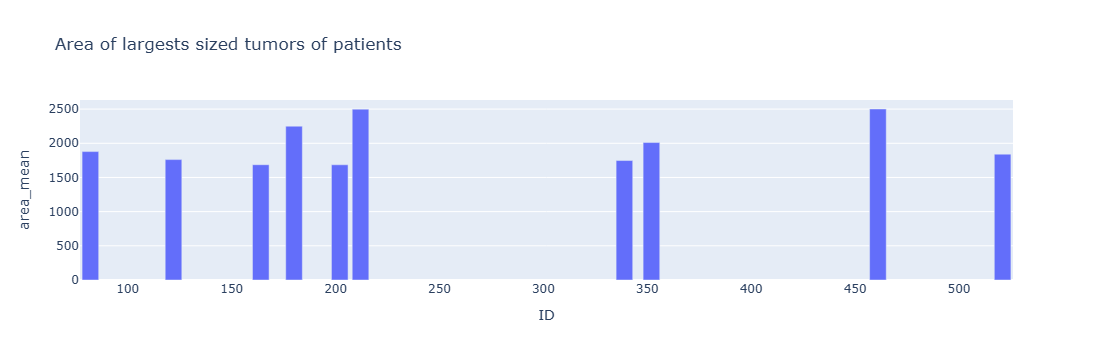

In [8]:
PATIENTS = size["id"]
labels = PATIENTS.index
SIZE = size["area_mean"]
figure = px.bar(size, x= labels, y= SIZE, title = 'Area of largests sized tumors of patients')
figure.update_layout(xaxis_title = 'ID')
figure.show()

In [9]:
#PERIMETE OF PATIENTS TUMOR

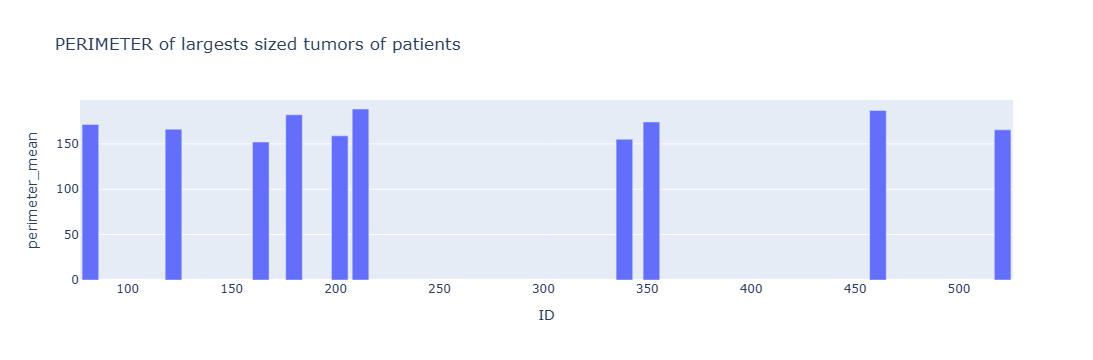

In [10]:
PATIENTS = size["id"]
labels = PATIENTS.index
SIZE = size["perimeter_mean"]
figure = px.bar(size, x= labels, y= SIZE, title = 'PERIMETER of largests sized tumors of patients')
figure.update_layout(xaxis_title = 'ID')
figure.show()

In [11]:
#graph between texture worst and area worst

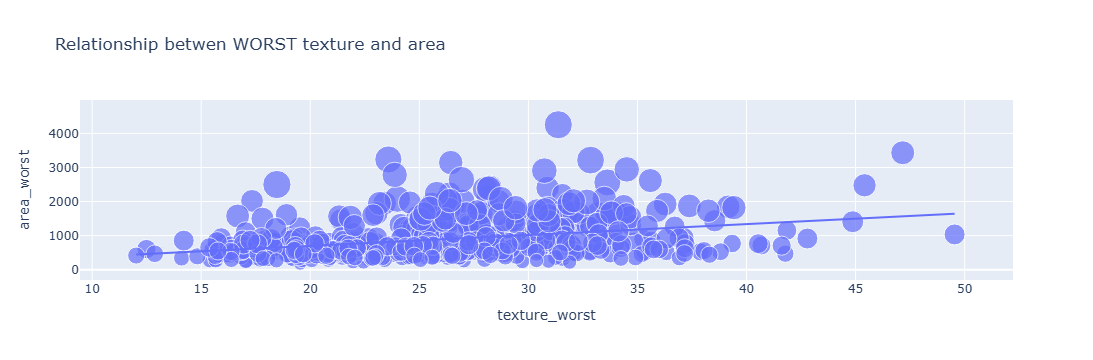

In [12]:
figure = px.scatter(data_frame = data, x ="texture_worst",y="area_worst",size = "perimeter_mean",trendline = "ols", title = "Relationship betwen WORST texture and area ")
figure.show()

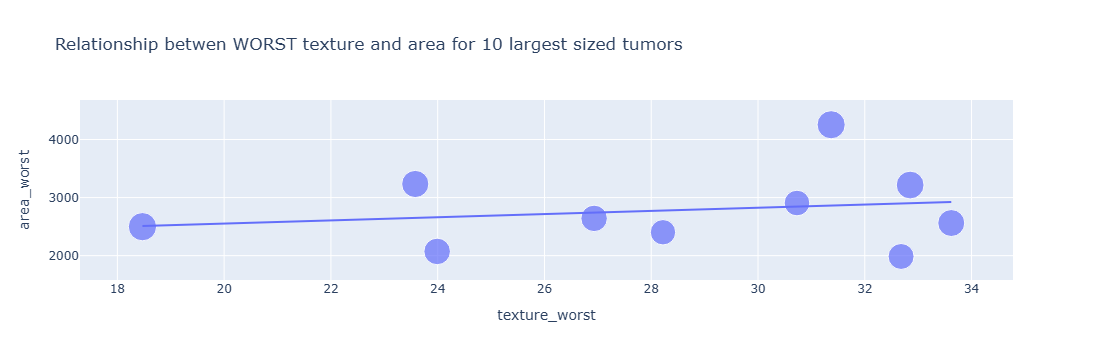

In [13]:
figure = px.scatter(data_frame = size, x ="texture_worst",y="area_worst",size = "perimeter_mean",trendline = "ols", title = "Relationship betwen WORST texture and area for 10 largest sized tumors")
figure.show()

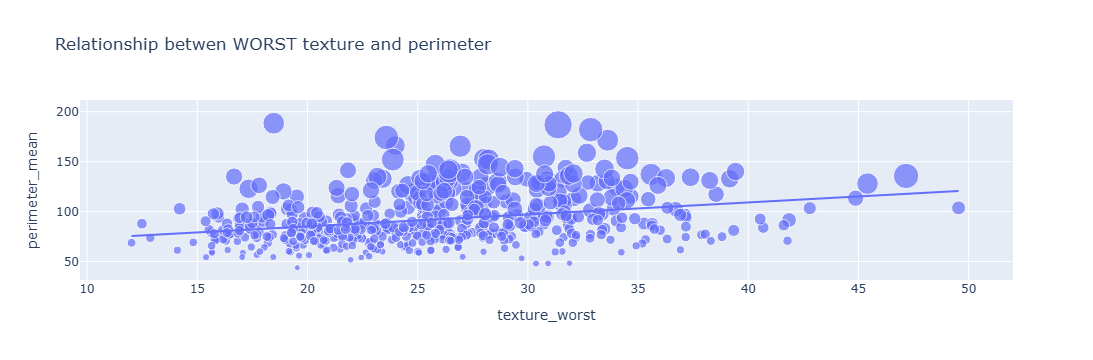

In [14]:
figure = px.scatter(data_frame = data, x ="texture_worst",y="perimeter_mean",size = "area_worst",trendline = "ols", title = "Relationship betwen WORST texture and perimeter ")
figure.show()

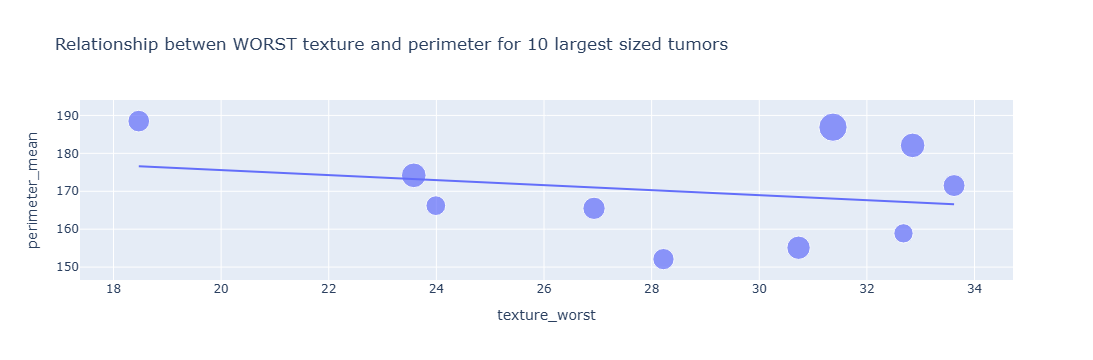

In [15]:
figure = px.scatter(data_frame = size, x ="texture_worst",y="perimeter_mean",size = "area_worst",trendline = "ols", title = "Relationship betwen WORST texture and perimeter for 10 largest sized tumors")
figure.show()

In [17]:
 # from above 2 graphs we can see that for 10 largest sized tumor the trend decreases but for overall data the trend is increases between WORST texture and perimeter

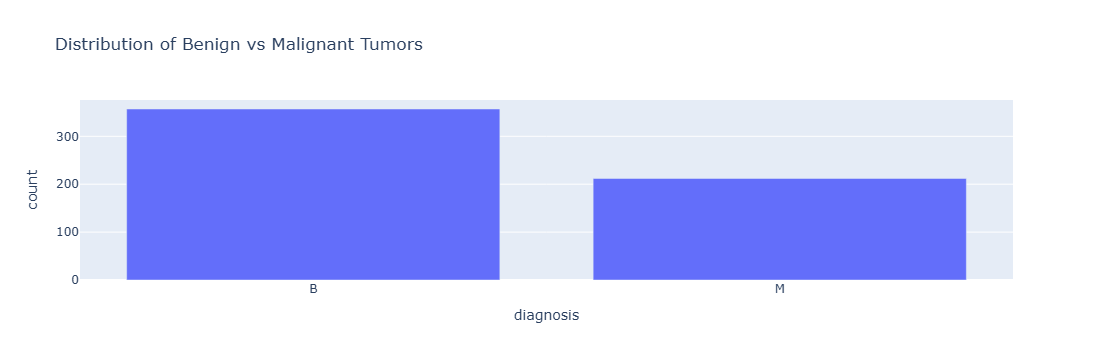

In [18]:
figure = px.bar(data['diagnosis'].value_counts().reset_index(),x='diagnosis',y= 'count',title = 'Distribution of Benign vs Malignant Tumors' )
figure.show()

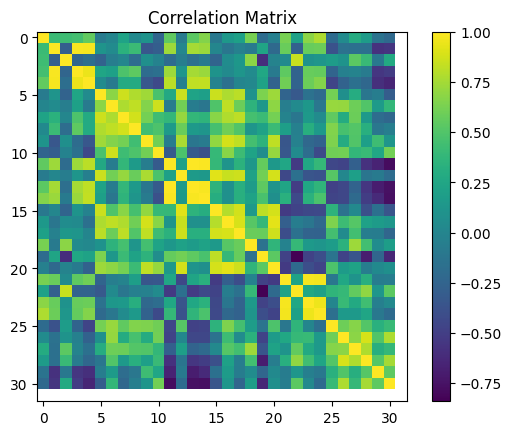

In [23]:
correlation = size.corr(numeric_only = True)
plt.figure()
plt.imshow(correlation)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()